In [2]:
import numpy as np
import matplotlib.pyplot as plt

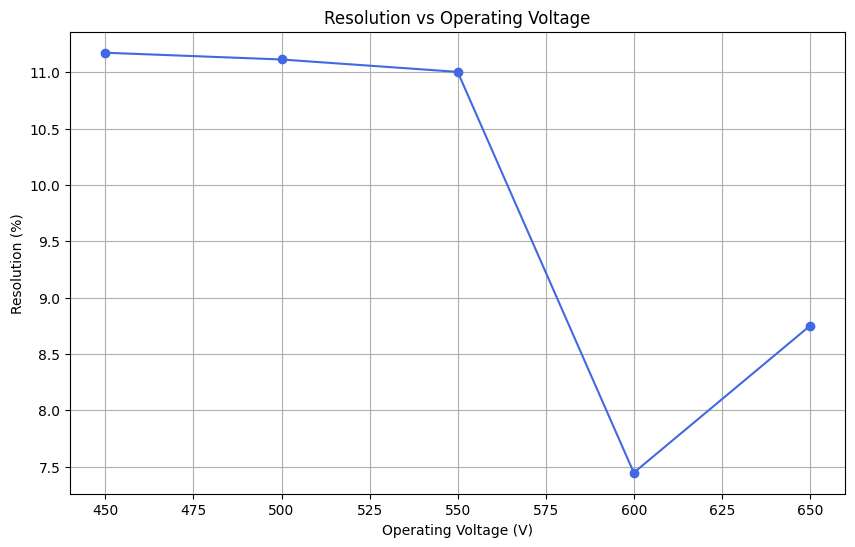

In [ ]:
# SCA Plots are done in origin 

# resolution vs operating voltage

v = np.array([450, 500, 550, 600, 650])  # Operating voltage in volts
resolution = np.array([11.173,11.113,11.003,7.447 ,8.750 ])  # Resolution % 
plt.figure(figsize=(10, 6))
plt.plot(v, resolution, marker='o', linestyle='-', color='royalblue')
plt.xlabel('Operating Voltage (V)')
plt.ylabel('Resolution (%)')
plt.title('Resolution vs Operating Voltage')
plt.grid(True)
plt.show()

Net Count for 150 seconds: [39976, 36184, 32256, 28173, 25823, 23290, 21031, 19143, 17115, 15347, 13760, 12419, 11360]


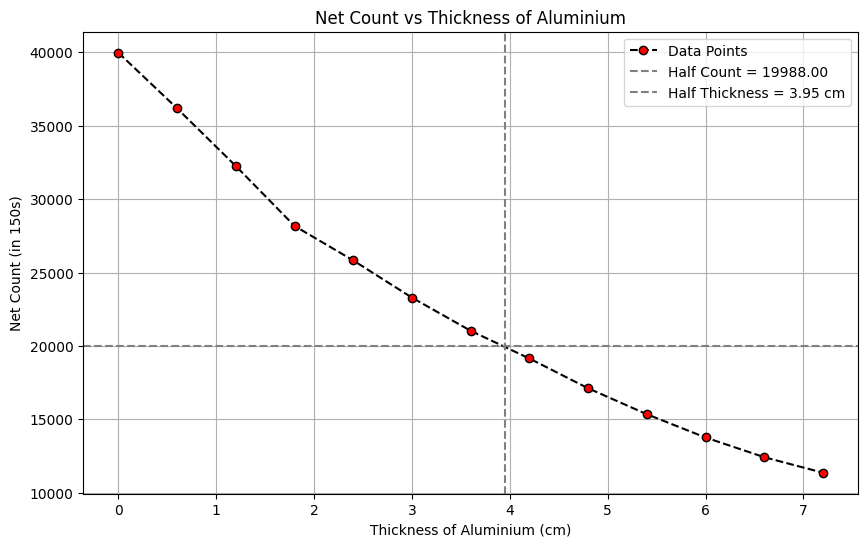

In [22]:
# Mass absorbance of Aluminium 
bg_count = 1612 # for 150 seconds
t = [0,0.6,1.2,1.8,2.4,3.0,3.6,4.2,4.8,5.4,6.0,6.6,7.2] # thickness in cm
gross_count = [41588,37796,33868,29785,27435,24902,22643,20755,18727,16959,15372,14031,12972] # gross count for 150 seconds
net_count = [g- bg_count for g in gross_count] # net count for 150 seconds
print("Net Count for 150 seconds:", net_count)
half_count = net_count[0] / 2 # half count for 150 seconds
half_thickness = ((t[8]-t[7])/(net_count[8]-net_count[7]))*(half_count - net_count[7]) + t[7]

plt.figure(figsize=(10, 6))
plt.plot(t, net_count, marker='o',markerfacecolor='red', linestyle='--', color='black', label='Data Points')
plt.axhline(y=half_count, color='grey', linestyle='--', label='Half Count = {:.2f}'.format(half_count))
plt.axvline(x=half_thickness, color='grey', linestyle='--', label='Half Thickness = {:.2f}'.format(half_thickness) +' cm')
plt.xlabel('Thickness of Aluminium (cm)')
plt.ylabel('Net Count (in 150s)')
plt.title('Net Count vs Thickness of Aluminium')
plt.grid(True)
plt.legend()
plt.show()


Peak channels: [166 206 255 296 336 379 423 465 506 578]


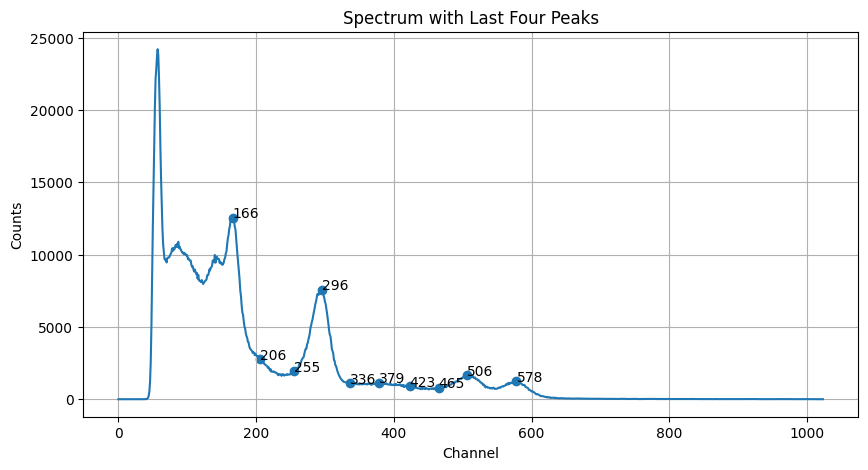

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

filename = "mix_source_cscoBa.txt"

# Read counts
counts = []
with open(filename, "r") as f:
    lines = f.readlines()

# Skip header
for line in lines[6:]:
    line = line.strip()
    if line != "":
        counts.append(int(line))

counts = np.array(counts)

# Channel numbers
channels = np.arange(len(counts))

# Find peaks
peaks, _ = find_peaks(counts, height=500, distance=40)

# Take last four peaks (highest channel numbers)
last_four = peaks[-10:]

print("Peak channels:", last_four)

# Plot
plt.figure(figsize=(10,5))
plt.plot(channels, counts)

# Mark peaks
plt.scatter(last_four, counts[last_four], marker='o')
for p in last_four:
    plt.text(p, counts[p], f"{p}")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Spectrum with Last Four Peaks")
plt.grid(True)
plt.show()
# i need only 1st,2nd,7th,10th peaks


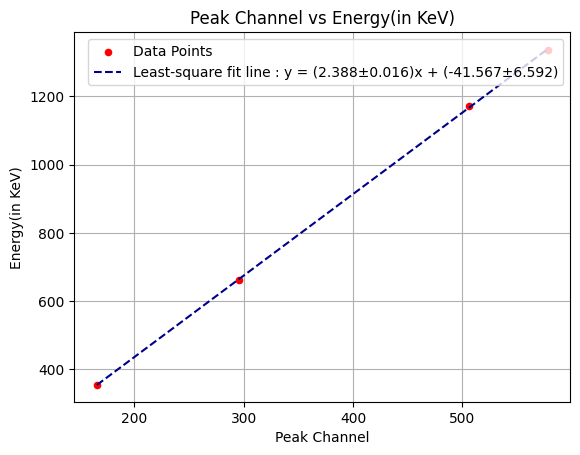

In [6]:
# fit data


def least_square_fitting(X, Y,X_axis,Y_axis,plot):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)

    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        plt.title(X_axis + " vs " + Y_axis)
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='red')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit
        plt.plot(x_fit,y_fit,'--',c='darkblue', label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')
        plt.legend()
        plt.show()

Energy_ = [356,662,1172,1335] # KeV
peak_channel = [166,296,506,578]

least_square_fitting(peak_channel,Energy_,"Peak Channel","Energy(in KeV)",True)

